# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [1]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [2]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [3]:
print(iris.keys())
print('filename:', iris.get('filename', 'built-in dataset'))
print('data shape:', iris.data.shape)
print('target shape:', iris.target.shape)
print('?10???:')
print(iris.data[:10])
print('????:', type(iris.data))
print('?10???:', iris.target[:10])


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
filename: iris.csv
data shape: (150, 4)
target shape: (150,)
?10???:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
????: <class 'numpy.ndarray'>
?10???: [0 0 0 0 0 0 0 0 0 0]


In [4]:
# we only take the first two features. 
data = iris.data
target = iris.target
X = iris.data[:, :2]
Y = iris.target
print(X.shape)


(150, 2)


In [5]:
#以下是組成 pandas DataFrame (也可以不用這種做)
x = pd.DataFrame(data, columns=iris['feature_names'])
x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [6]:
print(iris['data'].size)
print("target_names: " + str(iris['target_names']))
print("feature_names: " + str(iris['feature_names']))


600
target_names: ['setosa' 'versicolor' 'virginica']
feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
#??Target?????
y = pd.DataFrame(target, columns=['target'])
y.head()


,target
0,0
1,0
2,0
3,0
4,0


In [8]:
#?????????????
iris_data = pd.concat([x, y], axis=1)
iris_data.head(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [9]:
#??????0?1???
iris_data = iris_data[iris_data['target'].isin([0, 1])]
iris_data = iris_data[['sepal length (cm)', 'petal length (cm)', 'target']]
iris_data.head()


,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


## 切分訓練集與測試集
> train_test_split()

In [10]:
from sklearn.model_selection import train_test_split

feature_cols = ['sepal length (cm)', 'petal length (cm)']
X = iris_data[feature_cols]
y = iris_data['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)


X_train: (70, 2)
X_test: (30, 2)


In [11]:
X_train.head()

,sepal length (cm),petal length (cm)
86,6.7,4.7
54,6.5,4.6
52,6.9,4.9
65,6.7,4.4
76,6.8,4.8


In [12]:
X_test.head()

,sepal length (cm),petal length (cm)
38,4.4,1.3
43,5.0,1.6
84,5.4,4.5
23,5.1,1.7
42,4.4,1.3


# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [13]:
def norm_stats(dfs):
    minimum = dfs.min()
    maximum = dfs.max()
    mu = dfs.mean()
    sigma = dfs.std(ddof=0)
    return (minimum, maximum, mu, sigma)


def z_score(col, stats):
    m, M, mu, s = stats
    df = pd.DataFrame()
    for c in col.columns:
        df[c] = (col[c] - mu[c]) / s[c]
    return df


In [14]:
stats = norm_stats(X_train)
arr_x_train = np.array(z_score(X_train, stats))
arr_y_train = np.array(y_train)
arr_x_train[:5]

array([[1.94114606, 1.29689348],
       [1.62587872, 1.22635537],
       [2.2564134 , 1.43796969],
       [1.94114606, 1.08527916],
       [2.09877973, 1.36743159]])

## use sklearn

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.46857143 2.86142857]
[0.63438223 1.41767343]


In [16]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[1.94114606, 1.29689348],
       [1.62587872, 1.22635537],
       [2.2564134 , 1.43796969],
       [1.94114606, 1.08527916],
       [2.09877973, 1.36743159]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [17]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[-1.68442837 -1.10140215]
 [-0.73862634 -0.88978783]
 [-0.10809166  1.15581726]
 [-0.58099267 -0.81924973]
 [-1.68442837 -1.10140215]
 [ 0.04954201  0.80312673]
 [ 0.36480935  1.15581726]
 [ 0.83771037  1.15581726]
 [ 1.15297771  1.01474105]
 [-0.10809166 -0.81924973]]


you can also use fit_transform method (i.e., fit and then transform)    

In [18]:
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)
print(X_test_std[:10])


[[-1.68442837 -1.10140215]
 [-0.73862634 -0.88978783]
 [-0.10809166  1.15581726]
 [-0.58099267 -0.81924973]
 [-1.68442837 -1.10140215]
 [ 0.04954201  0.80312673]
 [ 0.36480935  1.15581726]
 [ 0.83771037  1.15581726]
 [ 1.15297771  1.01474105]
 [-0.10809166 -0.81924973]]


In [19]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 1.0


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


50.54219764489198
30.862292931934984


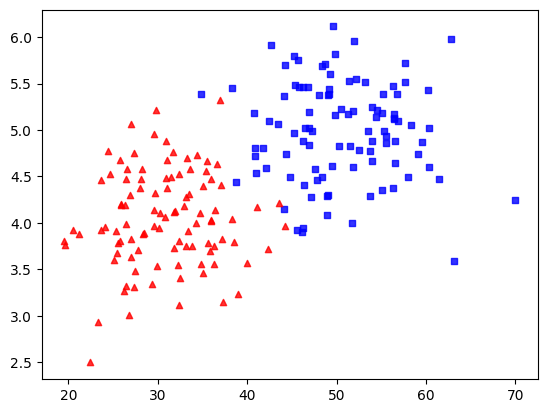

In [20]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

In [21]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [22]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [23]:
minmax_norm(x_val[:10])

array([0.61915055, 0.        , 0.51194089, 0.73785584, 0.85220024,
       0.20859995, 0.32878796, 0.1938373 , 0.22325334, 1.        ])

In [24]:
from sklearn.preprocessing import MinMaxScaler
x_val=x_val.reshape(-1, 1)
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.transform(x_val)[:10])

[69.98131253]
[[0.728215  ]
 [0.51841825]
 [0.69188742]
 [0.76843782]
 [0.80718297]
 [0.58910153]
 [0.62982677]
 [0.58409926]
 [0.59406677]
 [0.85726434]]


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(random_state=42)
model.fit(X_train_std, y_train)
y_pred = model.predict(X_test_std)

print('accuracy:', accuracy_score(y_test, y_pred))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=iris.target_names[:2]))


accuracy: 1.0
confusion matrix:
[[15  0]
 [ 0 15]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

